## Install Required Packages

**Run this cell first** to install all required libraries before importing them.

In [3]:
# Install required packages
# Run this cell first if you get "ModuleNotFoundError"

!pip install -q pandas numpy matplotlib seaborn scikit-learn gensim tensorflow

print("✓ All required packages installed successfully!")
print("You can now proceed to import libraries in the next cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.3 MB/s eta 0:00:00
✓ All required packages installed successfully!
You can now proceed to import libraries in the next cell.


# Data Collection Module — Tamil Fake News Detection

**UG Creative and Innovative Project (CIP) - Anna University**

This notebook contains **Module 1: Data Collection** with:
- Dataset loading and inspection
- Detailed data analytics and statistics
- Label and category distribution
- Feature extraction (text and labels) for downstream modules

## Import Required Libraries

In [4]:
# Standard libraries
import pandas as pd
import numpy as np
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from gensim.models import Word2Vec, FastText

# Model (Module 4)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import L2
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


## Upload Dataset File

**IMPORTANT:** Before running the Data Collection module, you need to upload the dataset file.

**Option 1: Use the file browser (Easiest)**
1. Click the 📁 folder icon in the left sidebar
2. Click the ⬆️ upload icon
3. Select `Tamil-News-Headlines.csv` from your computer
4. Wait for upload to complete

**Option 2: Use the code cell below** (Alternative method)

In [ ]:
# OPTIONAL: Upload dataset file using code (e.g. in Google Colab)
# If you already uploaded using the file browser, or run locally with file in folder, skip this cell

try:
    from google.colab import files
    print("Click the button below to upload Tamil-News-Headlines.csv")
    print("After uploading, the file will be available in the current directory.")
    uploaded = files.upload()
except ImportError:
    print("Not in Colab — ensure Tamil-News-Headlines.csv is in the current directory.")

# Verify file
import os
if 'Tamil-News-Headlines.csv' in os.listdir('.'):
    print("\n✓ File found!")
    print(f"File size: {os.path.getsize('Tamil-News-Headlines.csv')} bytes")
else:
    print("\n⚠ File not found. Please upload or place Tamil-News-Headlines.csv in the current directory.")

Click the button below to upload Tamil-News-Headlines.csv
After uploading, the file will be available in the current directory.


Saving Tamil-News-Headlines.csv to Tamil-News-Headlines (1).csv

✓ File found!
File size: 2066315 bytes


---

# Module 1: Data Collection Module

**Objectives:**
- Load the provided dataset
- Inspect dataset structure, columns, and labels
- Detailed data analytics and statistics
- Verify fake/real label distribution
- Extract features (text) and labels for downstream use

In [5]:
# Load the dataset
dataset_path = 'Tamil-News-Headlines.csv'
df = pd.read_csv(dataset_path)

print("="*60)
print("MODULE 1: DATA COLLECTION")
print("="*60)

# Basic dataset information
print("\n1. Dataset Shape:")
print(f"   Total rows: {df.shape[0]}")
print(f"   Total columns: {df.shape[1]}")

print("\n2. Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n3. First few rows:")
print(df.head())

print("\n4. Dataset Info:")
print(df.info())

print("\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("   No missing values found")

print("\n6. Data Types:")
print(df.dtypes)

MODULE 1: DATA COLLECTION

1. Dataset Shape:
   Total rows: 5226
   Total columns: 7

2. Column Names:
   1. Unnamed: 0
   2. English Version
   3. Label
   4. News
   5. Author
   6. Date
   7. Authenticity

3. First few rows:
   Unnamed: 0                                    English Version Label  \
0           0  Additional charge for users who share password...  tech   
1           1  Production of 'AK-203' guns in India by the en...  tech   
2           2  Moto E22s smartphone launched in India at a bu...  tech   
3           3            Let's make Kalam's last dream come true  tech   
4           4  Redmi A1+ smartphone launched in India at a bu...  tech   

                                                News          Author  \
0   பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம...  செய்திப்பிரிவு   
1   இந்தியாவில் நடப்பு ஆண்டின் இறுதிக்குள் ‘ஏகே-2...  செய்திப்பிரிவு   
2   பட்ஜெட் விலையில் மோட்டோ E22s ஸ்மார்ட்போன் இந்...  செய்திப்பிரிவு   
3             கலாம் கண்ட கடைசி கனவை நனவ


7. Descriptive Statistics (numeric columns):
        Unnamed: 0  Authenticity
count  5226.000000    5226.00000
mean   1336.431114       0.55530
std     795.826296       0.49698
min       0.000000       0.00000
25%     653.000000       0.00000
50%    1311.500000       1.00000
75%    1982.750000       1.00000
max    2948.000000       1.00000

8. Label Distribution (Authenticity column):
Authenticity
0    2324
1    2902
Name: count, dtype: int64

   Fake (0): 2324 samples (44.47%)
   Real (1): 2902 samples (55.53%)


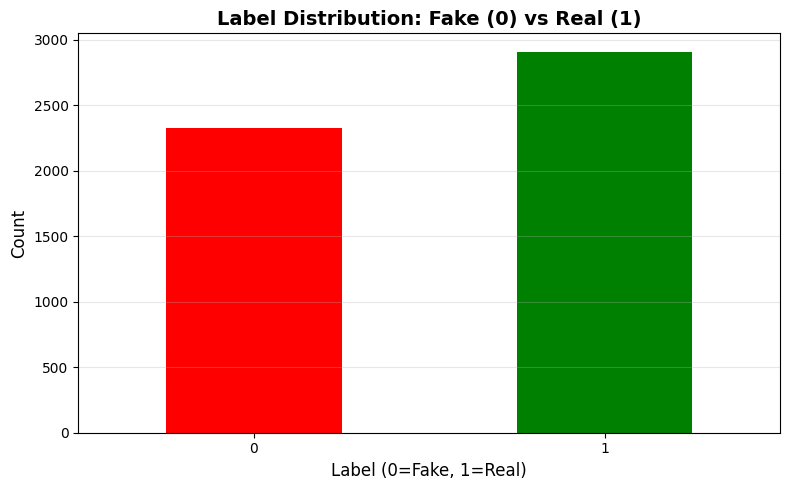


9. Category Distribution (Label column):
Label
politics         1674
miscellaneous    1521
tech              966
entertainment     589
sport             476
Name: count, dtype: int64


In [6]:
# Detailed statistics: numeric and categorical columns
print("\n7. Descriptive Statistics (numeric columns):")
if df.select_dtypes(include=[np.number]).columns.any():
    print(df.describe())
else:
    print("   No numeric columns.")

print("\n8. Label Distribution (Authenticity column):")
label_counts = df['Authenticity'].value_counts().sort_index()
print(label_counts)
print(f"\n   Fake (0): {label_counts.get(0, 0)} samples ({label_counts.get(0, 0)/len(df)*100:.2f}%)")
print(f"   Real (1): {label_counts.get(1, 0)} samples ({label_counts.get(1, 0)/len(df)*100:.2f}%)")

# Visualize label distribution
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color=['red', 'green'])
plt.title('Label Distribution: Fake (0) vs Real (1)', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Fake, 1=Real)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n9. Category Distribution (Label column):")
category_counts = df['Label'].value_counts()
print(category_counts)


10. Text (News) Column — Detailed Statistics:
    Character count — Min: 9, Max: 404, Mean: 89.15, Std: 47.39
    Median length: 79 characters
    Word count (approx) — Min: 1, Max: 44, Mean: 10.09


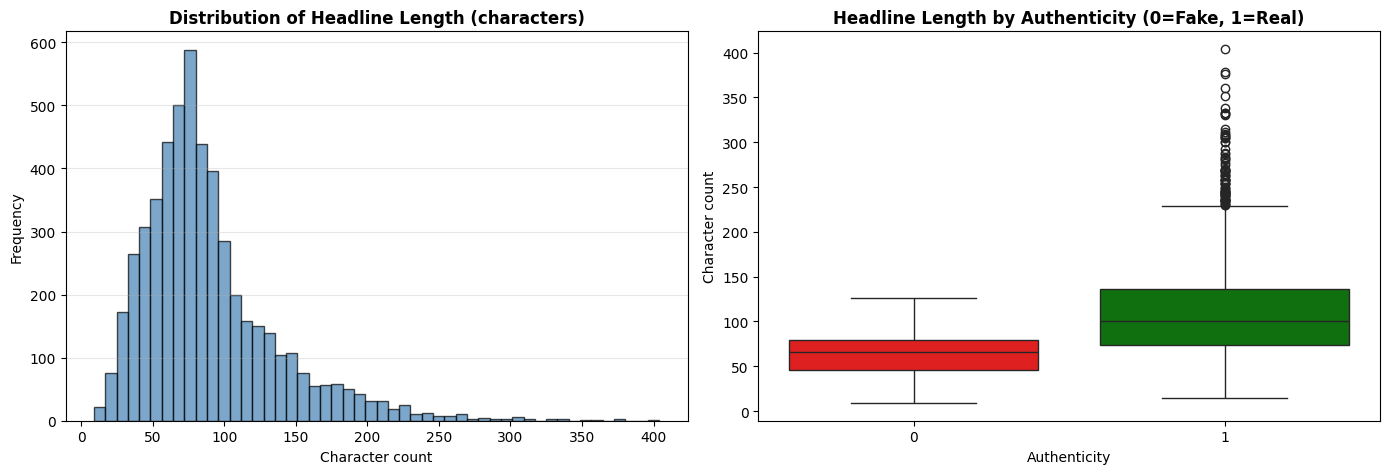

In [7]:
# Detailed analytics: text (News) column statistics
print("\n10. Text (News) Column — Detailed Statistics:")
text_lengths = df['News'].astype(str).str.len()
print(f"    Character count — Min: {text_lengths.min()}, Max: {text_lengths.max()}, Mean: {text_lengths.mean():.2f}, Std: {text_lengths.std():.2f}")
print(f"    Median length: {text_lengths.median():.0f} characters")

# Word count (approximate: split by spaces)
word_counts = df['News'].astype(str).str.split().str.len()
print(f"    Word count (approx) — Min: {word_counts.min()}, Max: {word_counts.max()}, Mean: {word_counts.mean():.2f}")

# Distribution of text length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(text_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Headline Length (characters)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

df_temp = df.assign(News_len=text_lengths)
sns.boxplot(data=df_temp, x='Authenticity', y='News_len', ax=axes[1], palette=['red', 'green'])
axes[1].set_title('Headline Length by Authenticity (0=Fake, 1=Real)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Authenticity')
axes[1].set_ylabel('Character count')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [8]:
# Sample data inspection
print("\n11. Sample Tamil News Headlines:")
print("\n   Sample Fake News (Authenticity=0):")
fake_samples = df[df['Authenticity'] == 0]['News'].head(3)
for idx, text in enumerate(fake_samples, 1):
    print(f"   {idx}. {text[:100]}..." if len(str(text)) > 100 else f"   {idx}. {text}")

print("\n   Sample Real News (Authenticity=1):")
real_samples = df[df['Authenticity'] == 1]['News'].head(3)
for idx, text in enumerate(real_samples, 1):
    print(f"   {idx}. {text[:100]}..." if len(str(text)) > 100 else f"   {idx}. {text}")

# Feature extraction: extract text (features) and labels for downstream modules
X_raw = df['News'].astype(str)   # Tamil text — input feature
y = df['Authenticity'].values    # Labels: 0=Fake, 1=Real — target

print(f"\n12. Extracted Data (Feature Extraction):")
print(f"    X_raw (Text): {len(X_raw)} samples")
print(f"    y (Labels): {len(y)} samples")
print(f"    Label distribution: {np.bincount(y)}")
print(f"    Unique labels: {np.unique(y)}")

print("\n" + "="*60)
print("MODULE 1 COMPLETED: Dataset loaded, analyzed, and features extracted successfully!")
print("="*60)


11. Sample Tamil News Headlines:

   Sample Fake News (Authenticity=0):
   1.  பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்  
   2.  இந்தியாவில் நடப்பு ஆண்டின் இறுதிக்குள் ‘ஏகே-203’ ரக துப்பாக்கிகள் தயாரிப்பு?   
   3.  பட்ஜெட் விலையில் மோட்டோ E22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் | விலை &...   

   Sample Real News (Authenticity=1):
   1. COVID-19 வைரஸ் "இல்லை" என்கிறார்.
   2. கொரோனா வைரஸ் வெறும் "அடடா காய்ச்சல்" என்று கூறுகிறார்.
   3. கொரோனா வைரஸ் "நம்மிடம் பதுங்கியிருந்தது," இது "மிகவும் எதிர்பாராத விஷயம்" என்றும் கூறினார்.

12. Extracted Data (Feature Extraction):
    X_raw (Text): 5226 samples
    y (Labels): 5226 samples
    Label distribution: [2324 2902]
    Unique labels: [0 1]

MODULE 1 COMPLETED: Dataset loaded, analyzed, and features extracted successfully!


---

# Module 2: Tamil-Specific Text Preprocessing Module

**Objectives:**
- Unicode Tamil handling
- Noise removal (URLs, email, special symbols, emojis)
- Normalization
- Basic code-mixed text handling (Tamil–English)
- Tokenization
- Stopword removal (Tamil-specific)
- Lightweight stemming (rule-based)

**Dataset size (5226 samples):** Preprocessing is kept moderate—lightweight stemming and a focused stopword list—to preserve discriminative signal and avoid overfitting or reduced accuracy.

In [9]:
# Tamil stopwords (common Tamil stopwords — moderate list for 5226 samples)
tamil_stopwords = [
    'என்பது', 'என்று', 'என', 'என்ற', 'என்பதை', 'என்பதன்', 'என்பதின்',
    'இது', 'இதை', 'இதன்', 'இதில்', 'இதிலிருந்து', 'இதற்கு', 'இதைப்', 'இதை',
    'அது', 'அதை', 'அதன்', 'அதில்', 'அதிலிருந்து', 'அதற்கு', 'அதைப்',
    'எது', 'எதை', 'எதன்', 'எதில்', 'எதற்கு',
    'ஒரு', 'ஒன்று', 'ஒரே', 'ஒருவர்', 'ஒருவரை', 'ஒருவரின்',
    'மற்றும்', 'மேலும்', 'அல்லது', 'ஆனால்', 'எனினும்',
    'இந்த', 'இந்தப்', 'இந்தத்', 'இந்த ந',
    'அந்த', 'அந்தப்', 'அந்தத்', 'அந்த ந',
    'எந்த', 'எந்தப்', 'எந்தத்',
    'உள்ள', 'இருக்கும்', 'இருக்கிறது', 'இருக்கின்றன',
    'ஆக', 'ஆகும்', 'ஆகிய', 'ஆகவும்',
    'உம்', 'உடன்', 'உள்ளே', 'வெளியே',
    'மீது', 'மேல்', 'கீழ்', 'பின்', 'முன்',
    'ஆன', 'ஆனது', 'ஆனால்',
    'போது', 'போல', 'போன்ற',
    'வேண்டும்', 'வேண்டிய', 'வேண்ட',
    'கொண்டு', 'கொண்ட', 'கொண்டிருக்கும்',
    'செய்து', 'செய்த', 'செய்திருக்கும்', 'செய்ய', 'செய்யும்',
    'பெற்று', 'பெற்ற', 'பெற', 'பெறும்',
    'உள்ளது', 'இல்லை', 'இருக்கிறது',
    'என்றால்', 'எனில்',
    'அல்லது', 'அல்ல',
    'மட்டும்', 'மட்டுமே',
    'கூட', 'கூடிய',
    'பல', 'பலர்', 'பலவற்றை',
    'சில', 'சிலர்', 'சிலவற்றை',
    'அனைத்தும்', 'அனைத்தையும்',
    'எல்லா', 'எல்லாம்', 'எல்லாவற்றையும்',
    'நான்', 'நாம்', 'நாங்கள்',
    'நீ', 'நீங்கள்',
    'அவன்', 'அவள்', 'அவர்', 'அவர்கள்',
    'இது', 'இவை',
    'அது', 'அவை',
    'எது', 'எவை'
]

print("Tamil stopwords list loaded.")
print(f"Total stopwords: {len(tamil_stopwords)}")

Tamil stopwords list loaded.
Total stopwords: 124


In [10]:
# Preprocessing step functions (for before/after display) and full pipeline
def step1_unicode_handling(text):
    """Unicode Tamil handling: preserve Tamil 0B80-0BFF; ensure str."""
    if pd.isna(text) or text == '':
        return ''
    return str(text)

def step2_noise_removal(text):
    """Remove URLs, emails, special symbols, emojis; collapse whitespace."""
    if not text:
        return ''
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^\u0B80-\u0BFFa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def step3_normalization(text):
    """Lowercase English parts; Tamil unchanged (no case)."""
    if not text:
        return ''
    words = text.split()
    normalized = []
    for w in words:
        if re.search(r'[a-zA-Z]', w):
            w = w.lower()
        normalized.append(w)
    return ' '.join(normalized)

def step4_code_mixed_handling(text):
    """Keep Tamil and English; no transliteration (handled in normalization)."""
    return text

def step5_tokenization(text):
    """Tokenize by whitespace."""
    return text.split() if text else []

def step6_stopword_removal(tokens, stopwords_list):
    """Remove Tamil stopwords."""
    return [t for t in tokens if t not in stopwords_list]

def step7_lightweight_stemming(tokens):
    """Rule-based Tamil suffix removal (lightweight for 5226 samples)."""
    result = []
    for token in tokens:
        if len(token) > 3:
            if token.endswith('க்கு') or token.endswith('க்கும்'):
                token = token[:-3]
            elif token.endswith('க்க'):
                token = token[:-2]
            elif token.endswith('த்தில்') or token.endswith('த்தை') or token.endswith('த்தின்'):
                token = token[:-4]
            elif token.endswith('த்த'):
                token = token[:-2]
            elif token.endswith('ங்களை'):
                token = token[:-4]
            elif token.endswith('ங்கள்'):
                token = token[:-3]
        if len(token) > 0:
            result.append(token)
    return result

def preprocess_tamil_text(text, stopwords_list):
    """Full pipeline: all 7 steps. Returns preprocessed string."""
    if pd.isna(text) or text == '':
        return ''
    text = step1_unicode_handling(text)
    text = step2_noise_removal(text)
    text = step3_normalization(text)
    text = step4_code_mixed_handling(text)
    tokens = step5_tokenization(text)
    tokens = step6_stopword_removal(tokens, stopwords_list)
    tokens = step7_lightweight_stemming(tokens)
    return ' '.join(tokens)

print("Preprocessing functions defined (step-wise + full pipeline).")

Preprocessing functions defined (step-wise + full pipeline).


In [11]:
# Find dataset rows where each sub-block actually CHANGES the text (real before/after)
def get_raw(i):
    t = X_raw.iloc[i] if hasattr(X_raw, 'iloc') else X_raw[i]
    return None if (pd.isna(t) or not str(t).strip()) else str(t)

idx_noise = None   # row where noise removal changes text (has : @ http www or symbols)
idx_norm = None   # row where normalization changes text (has uppercase English)
idx_stop = None   # row that contains Tamil stopwords
idx_stem = None   # row that has tokens we stem (end with Tamil suffixes)

for i in range(len(X_raw)):
    raw = get_raw(i)
    if not raw:
        continue
    t1 = step1_unicode_handling(raw)
    t2 = step2_noise_removal(t1)
    if t1 != t2 and idx_noise is None:
        idx_noise = i
    t3 = step3_normalization(t2)
    if t2 != t3 and idx_norm is None:
        idx_norm = i
    toks = step5_tokenization(t3)
    if idx_stop is None and any(t in tamil_stopwords for t in toks):
        idx_stop = i
    toks6 = step6_stopword_removal(toks, tamil_stopwords)
    toks7 = step7_lightweight_stemming(toks6)
    if idx_stem is None and toks6 != toks7:
        idx_stem = i
    if idx_noise is not None and idx_norm is not None and idx_stop is not None and idx_stem is not None:
        break

# Fallbacks: use first valid row for any missing
for i in [0, 1, 100, 500, 1000, 2000, 3000]:
    if i >= len(X_raw):
        break
    raw = get_raw(i)
    if not raw:
        continue
    if idx_noise is None:
        t1 = step1_unicode_handling(raw)
        t2 = step2_noise_removal(t1)
        if t1 != t2:
            idx_noise = i
    if idx_norm is None:
        t2 = step2_noise_removal(step1_unicode_handling(raw))
        t3 = step3_normalization(t2)
        if t2 != t3:
            idx_norm = i
    if idx_stop is None:
        t3 = step3_normalization(step2_noise_removal(step1_unicode_handling(raw)))
        if any(t in tamil_stopwords for t in step5_tokenization(t3)):
            idx_stop = i
    if idx_stem is None:
        t3 = step3_normalization(step2_noise_removal(step1_unicode_handling(raw)))
        toks = step6_stopword_removal(step5_tokenization(t3), tamil_stopwords)
        if step7_lightweight_stemming(toks) != toks:
            idx_stem = i

def show_ba(before_val, after_val, max_display=130, is_tokens=False):
    if is_tokens:
        b = str(before_val[:30]) + (" ..." if len(before_val) > 30 else "")
        a = str(after_val[:30]) + (" ..." if len(after_val) > 30 else "")
    else:
        s1, s2 = str(before_val), str(after_val)
        b = repr(s1[:max_display]) + ("..." if len(s1) > max_display else "")
        a = repr(s2[:max_display]) + ("..." if len(s2) > max_display else "")
    print(f"   BEFORE: {b}")
    print(f"   AFTER:  {a}")

print("="*70)
print("PREPROCESSING SUB-BLOCK OUTPUTS (Before/After — examples that SHOW effect)")
print("="*70)

# Use one rich example if we have it; else mix of indices
idx_unicode = 0
if idx_noise is None:
    idx_noise = idx_unicode
if idx_norm is None:
    idx_norm = idx_unicode
if idx_stop is None:
    idx_stop = idx_unicode
if idx_stem is None:
    idx_stem = idx_unicode

def run_steps(raw):
    t1 = step1_unicode_handling(raw)
    t2 = step2_noise_removal(t1)
    t3 = step3_normalization(t2)
    t4 = step4_code_mixed_handling(t3)
    toks5 = step5_tokenization(t4)
    toks6 = step6_stopword_removal(toks5, tamil_stopwords)
    toks7 = step7_lightweight_stemming(toks6)
    return t1, t2, t3, t4, toks5, toks6, toks7

# [1] Unicode — use first row
raw_u = get_raw(idx_unicode)
if raw_u:
    t1, _, _, _, _, _, _ = run_steps(raw_u)
    print(f"\n[1] UNICODE TAMIL HANDLING (dataset row {idx_unicode})")
    show_ba(raw_u, t1)
    print()

# [2] Noise removal — use row where noise actually changes text
raw_n = get_raw(idx_noise)
if raw_n:
    t1, t2, _, _, _, _, _ = run_steps(raw_n)
    print(f"[2] NOISE REMOVAL (dataset row {idx_noise} — has symbols/URL/email/punctuation)")
    show_ba(t1, t2)
    print()

# [3] Normalization — use row where lowercase changes text
raw_norm = get_raw(idx_norm)
if raw_norm:
    _, t2, t3, _, _, _, _ = run_steps(raw_norm)
    print(f"[3] NORMALIZATION (dataset row {idx_norm} — has English to lowercase)")
    show_ba(t2, t3)
    print()

# [4] Code-mixed — same as normalization (no change step; show retained text)
raw_c = get_raw(idx_norm or 0)
if raw_c:
    _, _, t3, t4, _, _, _ = run_steps(raw_c)
    print(f"[4] BASIC CODE-MIXED TEXT HANDLING (dataset row {idx_norm or 0} — Tamil+English retained)")
    show_ba(t3, t4)
    print()

# [5] Tokenization — any row
raw_t = get_raw(0)
if raw_t:
    _, _, _, t4, toks5, _, _ = run_steps(raw_t)
    print(f"[5] TOKENIZATION (dataset row 0)")
    print(f"   BEFORE (string): {repr(t4[:100])}{'...' if len(t4) > 100 else ''}")
    print(f"   AFTER (tokens):  {toks5[:25]}{' ...' if len(toks5) > 25 else ''}  (count={len(toks5)})")
    print()

# [6] Stopword removal — use row that has stopwords
raw_s = get_raw(idx_stop)
if raw_s:
    _, _, _, _, toks5, toks6, _ = run_steps(raw_s)
    removed = [t for t in toks5 if t in tamil_stopwords]
    print(f"[6] STOPWORD REMOVAL (dataset row {idx_stop} — contains Tamil stopwords)")
    print(f"   BEFORE (token count): {len(toks5)}  tokens: {toks5[:20]}{' ...' if len(toks5) > 20 else ''}")
    print(f"   AFTER (token count):  {len(toks6)}  tokens: {toks6[:20]}{' ...' if len(toks6) > 20 else ''}")
    if removed:
        print(f"   Removed stopwords: {removed}")
    print()

# [7] Stemming — use row that has stemmable tokens
raw_st = get_raw(idx_stem)
if raw_st:
    _, _, _, _, _, toks6, toks7 = run_steps(raw_st)
    pairs = [(toks6[i], toks7[i]) for i in range(min(len(toks6), len(toks7))) if toks6[i] != toks7[i]]
    print(f"[7] LIGHTWEIGHT STEMMING (dataset row {idx_stem} — tokens with Tamil suffixes)")
    print(f"   BEFORE (tokens): {toks6[:25]}{' ...' if len(toks6) > 25 else ''}")
    print(f"   AFTER (tokens):  {toks7[:25]}{' ...' if len(toks7) > 25 else ''}")
    if pairs:
        print(f"   Stemmed (before -> after): {pairs[:8]}")
    print()

# [FINAL] Show full pipeline on one rich example
rich_idx = idx_stem if idx_stem is not None else idx_stop if idx_stop is not None else 0
raw_f = get_raw(rich_idx)
if raw_f:
    _, _, _, _, _, toks6, toks7 = run_steps(raw_f)
    final_text = ' '.join(toks7)
    print(f"[FINAL] PREPROCESSED STRING (dataset row {rich_idx})")
    print(f"   Raw:    {repr(raw_f[:120])}{'...' if len(raw_f) > 120 else ''}")
    print(f"   Final:  {repr(final_text[:120])}{'...' if len(final_text) > 120 else ''}")

print("\n" + "="*70)

PREPROCESSING SUB-BLOCK OUTPUTS (Before/After — examples that SHOW effect)

[1] UNICODE TAMIL HANDLING (dataset row 0)
   BEFORE: ' பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்  '
   AFTER:  ' பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்  '

[2] NOISE REMOVAL (dataset row 0 — has symbols/URL/email/punctuation)
   BEFORE: ' பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்  '
   AFTER:  'பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம் நெட்ஃப்ளிக்ஸ் பலே திட்டம்'

[3] NORMALIZATION (dataset row 2 — has English to lowercase)
   BEFORE: 'பட்ஜெட் விலையில் மோட்டோ E22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் விலை'
   AFTER:  'பட்ஜெட் விலையில் மோட்டோ e22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் விலை'

[4] BASIC CODE-MIXED TEXT HANDLING (dataset row 2 — Tamil+English retained)
   BEFORE: 'பட்ஜெட் விலையில் மோட்டோ e22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் விலை'
   AFTER:  'பட்ஜெட் விலையில் மோட்டோ e22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுக

In [12]:
# Apply preprocessing to full dataset (5226 samples)
print("="*60)
print("MODULE 2: APPLY PREPROCESSING TO FULL DATASET")
print("="*60)

print("\nPreprocessing all texts (this may take a moment)...")
X_preprocessed = X_raw.apply(lambda t: preprocess_tamil_text(t, tamil_stopwords))

# Statistics
original_lengths = X_raw.str.len()
preprocessed_lengths = X_preprocessed.str.len()
print(f"\n1. Preprocessing statistics:")
print(f"   Average original length:      {original_lengths.mean():.2f} characters")
print(f"   Average preprocessed length:  {preprocessed_lengths.mean():.2f} characters")
red_pct = ((original_lengths - preprocessed_lengths) / original_lengths.replace(0, 1) * 100).mean()
print(f"   Average length reduction:     {red_pct:.2f}%")

# Remove empty texts (avoid downstream issues)
non_empty_mask = X_preprocessed.str.len() > 0
X_preprocessed = X_preprocessed[non_empty_mask]
y_filtered = y[non_empty_mask.values]

print(f"\n2. After removing empty texts:")
print(f"   Remaining samples: {len(X_preprocessed)}")
print(f"   Removed samples:   {len(X_raw) - len(X_preprocessed)}")

print("\n3. Sample before/after (first 3 rows from dataset):")
for i in range(min(3, len(X_raw))):
    print(f"\n   Row {i}:")
    print(f"   BEFORE: {str(X_raw.iloc[i])[:100]}...")
    after = X_preprocessed.loc[i] if i in X_preprocessed.index else "(removed - empty)"
    print(f"   AFTER:  {str(after)[:100]}..." if isinstance(after, str) and len(str(after)) > 100 else f"   AFTER:  {after}")

print("\n" + "="*60)
print("MODULE 2 COMPLETED: Text preprocessing completed successfully!")
print("="*60)

MODULE 2: APPLY PREPROCESSING TO FULL DATASET

Preprocessing all texts (this may take a moment)...

1. Preprocessing statistics:
   Average original length:      89.15 characters
   Average preprocessed length:  77.92 characters
   Average length reduction:     11.97%

2. After removing empty texts:
   Remaining samples: 5226
   Removed samples:   0

3. Sample before/after (first 3 rows from dataset):

   Row 0:
   BEFORE:  பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்  ...
   AFTER:  பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம் நெட்ஃப்ளிக்ஸ் பலே திட்டம்

   Row 1:
   BEFORE:  இந்தியாவில் நடப்பு ஆண்டின் இறுதிக்குள் ‘ஏகே-203’ ரக துப்பாக்கிகள் தயாரிப்பு?   ...
   AFTER:  இந்தியாவில் நடப்பு ஆண்டின் இறுதிக்குள் ஏகே 203 ரக துப்பாக்கிகள் தயாரிப்பு

   Row 2:
   BEFORE:  பட்ஜெட் விலையில் மோட்டோ E22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் | விலை &...   ...
   AFTER:  பட்ஜெட் விலையில் மோட்டோ e22s ஸ்மார்ட்போன் இந்தியாவில் அறிமுகம் விலை

MODULE 2 COMPLETED: Text preproces

---

# Dataset Split (Before Feature Extraction — No Data Leakage)

**CRITICAL:** The train/validation/test split is done **here**, right after preprocessing and **before** any feature extraction (TF-IDF, Word2Vec, FastText, tokenizer). This ensures:
- TF-IDF vectorizer is fitted **only on training text**
- Word2Vec and FastText are trained **only on training text**
- Keras tokenizer is fitted **only on training text**
- Test set remains completely unseen until final evaluation

In [13]:
# Split BEFORE any feature extraction — prevents data leakage
TEST_SIZE = 0.2   # 20% held out for final test
VAL_SIZE = 0.2    # 20% of remaining 80% for validation (16% of total)
RANDOM_STATE = 42

# First split: 80% train+val, 20% test (stratified)
X_train_val_prep, X_test_prep, y_train_val, y_test = train_test_split(
    X_preprocessed,
    y_filtered,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_filtered
)

# Second split: from 80%, take 20% as validation (64% train, 16% val)
X_train_prep, X_val_prep, y_train, y_val = train_test_split(
    X_train_val_prep,
    y_train_val,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

n_total = len(y_filtered)
print("="*60)
print("DATASET SPLIT (before feature extraction — no leakage)")
print("="*60)
print(f"   Total samples:     {n_total}")
print(f"   Train:            {len(X_train_prep)} ({100*len(X_train_prep)/n_total:.1f}%)")
print(f"   Validation:       {len(X_val_prep)} ({100*len(X_val_prep)/n_total:.1f}%)")
print(f"   Test (held-out):   {len(X_test_prep)} ({100*len(X_test_prep)/n_total:.1f}%)")
print("   Label distribution per split:")
print(f"      Train      — Fake(0): {np.sum(y_train==0)}, Real(1): {np.sum(y_train==1)}")
print(f"      Validation — Fake(0): {np.sum(y_val==0)}, Real(1): {np.sum(y_val==1)}")
print(f"      Test       — Fake(0): {np.sum(y_test==0)}, Real(1): {np.sum(y_test==1)}")
print("="*60)

DATASET SPLIT (before feature extraction — no leakage)
   Total samples:     5226
   Train:            3344 (64.0%)
   Validation:       836 (16.0%)
   Test (held-out):   1046 (20.0%)
   Label distribution per split:
      Train      — Fake(0): 1487, Real(1): 1857
      Validation — Fake(0): 372, Real(1): 464
      Test       — Fake(0): 465, Real(1): 581


---

# Module 3: Feature Extraction Module

**Sub-blocks:**
1. **Input:** Preprocessed text (from Module 2)
2. **Feature selection:** Vocabulary and representation choices for our data
3. **Baseline feature extraction:** TF-IDF (bag-of-words style, strong baseline for short text)
4. **Deep learning feature representation:** Word2Vec and FastText (dense embeddings)
5. **Output:** Extracted feature vectors for downstream models

**Tuned for our dataset (~5226 samples, Tamil headlines):**
- **TF-IDF:** Unigrams + bigrams, `sublinear_tf=True` (log(1+tf)) for better discrimination, moderate `max_features` to reduce overfitting.
- **Word2Vec / FastText:** 100-dim embeddings, `min_count=2` to drop noise; FastText helps with Tamil morphology and OOV. Document vectors via **mean pooling** of word vectors for each headline (fixed-length vector per sample).

In [14]:
# ======================================================================
# MODULE 3: FEATURE EXTRACTION — Sub-block outputs (with respect to our data)
# ======================================================================

print("="*70)
print("MODULE 3: FEATURE EXTRACTION")
print("="*70)

# --- [1] INPUT: Preprocessed text (TRAIN only for fitting) ---
print("\n[1] INPUT: Preprocessed text (from Module 2 — split into train/val/test)")
print(f"    Train documents: {len(X_train_prep)} (used for fitting TF-IDF, Word2Vec, FastText)")
print(f"    Validation documents: {len(X_val_prep)} (transform only)")
print(f"    Test documents: {len(X_test_prep)} (transform only — held out)")
print(f"    Sample preprocessed texts (first 3 from TRAIN):")
for i in range(min(3, len(X_train_prep))):
    txt = X_train_prep.iloc[i] if hasattr(X_train_prep, 'iloc') else X_train_prep[i]
    print(f"      Train doc {i}: {str(txt)[:80]}...")
print("    Done: Fitting only on TRAIN to prevent data leakage.")

# --- [2] FEATURE SELECTION ---
# Tokenized texts for embeddings — TRAIN only for fitting
tokenized_texts_train = [str(t).split() for t in X_train_prep]
tokenized_texts_val = [str(t).split() for t in X_val_prep]
tokenized_texts_test = [str(t).split() for t in X_test_prep]
total_tokens_train = sum(len(t) for t in tokenized_texts_train)
vocab_raw = set()
for toks in tokenized_texts_train:
    vocab_raw.update(toks)

print("\n[2] FEATURE SELECTION (vocabulary from TRAIN only)")
print(f"    Tokenized train documents: {len(tokenized_texts_train)}")
print(f"    Total token occurrences (train): {total_tokens_train}")
print(f"    Unique tokens (raw vocabulary, train): {len(vocab_raw)}")
print(f"    Selection criteria for TF-IDF: max_features=4000, min_df=2, max_df=0.95, ngram_range=(1,2)")
print(f"    Selection for embeddings: min_count=2 (drop rare words), vector_size=100")
print("    Done: Vocabulary from TRAIN only — no leakage.")
print("="*70)

MODULE 3: FEATURE EXTRACTION

[1] INPUT: Preprocessed text (from Module 2 — split into train/val/test)
    Train documents: 3344 (used for fitting TF-IDF, Word2Vec, FastText)
    Validation documents: 836 (transform only)
    Test documents: 1046 (transform only — held out)
    Sample preprocessed texts (first 3 from TRAIN):
      Train doc 0: ீடு தேடி வரும் திருப்பதி லட்டு பிரசாதம் பக்தர்களுக காத்திருக்க அதிர்ச்சி...
      Train doc 1: 67 மாவட்டங்களில் புளோரிடாவில் 66 இடங்களில் வெற்றி பெற்றேன் முன்னோடியில்லாதது நடந...
      Train doc 2: indvspak ஃபார்முக திரும்ப வேண்டி பிராத்திக்கிறேன் கோலியிடம் தெரிவித...
    Done: Fitting only on TRAIN to prevent data leakage.

[2] FEATURE SELECTION (vocabulary from TRAIN only)
    Tokenized train documents: 3344
    Total token occurrences (train): 30990
    Unique tokens (raw vocabulary, train): 13117
    Selection criteria for TF-IDF: max_features=4000, min_df=2, max_df=0.95, ngram_range=(1,2)
    Selection for embeddings: min_count=2 (drop rare 

In [15]:
# --- [3] BASELINE FEATURE EXTRACTION: TF-IDF (fit on TRAIN only) ---
print("\n[3] BASELINE FEATURE EXTRACTION (TF-IDF)")

# Tuned for ~5226 samples, Tamil headlines: sublinear_tf improves discrimination; moderate max_features
tfidf_vectorizer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,  # use 1 + log(tf) — often better for classification
    encoding='utf-8'
)

# Fit on TRAIN only; transform train, val, test separately (no leakage)
tfidf_vectorizer.fit(X_train_prep.astype(str))
X_tfidf_train = tfidf_vectorizer.transform(X_train_prep.astype(str))
X_tfidf_val = tfidf_vectorizer.transform(X_val_prep.astype(str))
X_tfidf_test = tfidf_vectorizer.transform(X_test_prep.astype(str))

print(f"    What was done: Fitted TF-IDF on TRAIN only ({X_tfidf_train.shape[0]} docs); transform val/test.")
print(f"    Train TF-IDF shape: {X_tfidf_train.shape}")
print(f"    Val TF-IDF shape:   {X_tfidf_val.shape}")
print(f"    Test TF-IDF shape:  {X_tfidf_test.shape}")
feat_names = tfidf_vectorizer.get_feature_names_out()
print(f"    Sample feature names (first 20): {list(feat_names[:20])}")

# Show actual TF-IDF vector for first train document
first_doc_vec = X_tfidf_train.getrow(0)
nnz_cols = first_doc_vec.nonzero()[1][:15]
nnz_vals = first_doc_vec.toarray().flatten()[nnz_cols]
print(f"    First train document — 15 non-zero TF-IDF entries:")
for c, v in zip(nnz_cols, nnz_vals):
    name = feat_names[c] if c < len(feat_names) else str(c)
    print(f"       '{name}' -> {v:.4f}")
print("    Output: X_tfidf_train, X_tfidf_val, X_tfidf_test — no leakage.")


[3] BASELINE FEATURE EXTRACTION (TF-IDF)
    What was done: Fitted TF-IDF on TRAIN only (3344 docs); transform val/test.
    Train TF-IDF shape: (3344, 4000)
    Val TF-IDF shape:   (836, 4000)
    Test TF-IDF shape:  (1046, 4000)
    Sample feature names (first 20): ['000', '000 ஆண', '000 கள', '000 தல', '000 பட', '000 பவ', '000 வர', '000க', '04', '10', '10 ஆண', '10 பயனர', '10 யன', '10 லட', '100', '100 சதவ', '108', '108 ணவ', '11', '12']
    First train document — 15 non-zero TF-IDF entries:
       'அத' -> 0.2038
       'கள' -> 0.0997
       'கள அத' -> 0.3049
       'தம' -> 0.2085
       'தர' -> 0.2568
       'தர கள' -> 0.3312
       'பக' -> 0.2555
       'பக தர' -> 0.4094
       'பத' -> 0.1725
       'பத லட' -> 0.4216
       'ரச' -> 0.2695
       'லட' -> 0.3049
       'வர' -> 0.1745
    Output: X_tfidf_train, X_tfidf_val, X_tfidf_test — no leakage.


In [16]:
# --- [4] DEEP LEARNING FEATURE REPRESENTATION: Word2Vec (train on TRAIN only) ---
print("\n[4] DEEP LEARNING FEATURE REPRESENTATION (Word2Vec)")

# Parameters suited to ~5226 samples, short headlines
W2V_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_EPOCHS = 15
W2V_SG = 0  # CBOW — often more stable on smaller data

# Train on TRAIN tokenized texts only (no leakage)
word2vec_model = Word2Vec(
    sentences=tokenized_texts_train,
    vector_size=W2V_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    epochs=W2V_EPOCHS,
    sg=W2V_SG,
    seed=42
)

w2v_vocab = list(word2vec_model.wv.key_to_index.keys())
print(f"    What was done: Trained Word2Vec (CBOW) on TRAIN tokenized headlines only.")
print(f"    Vocabulary size (words with min_count>=2): {len(w2v_vocab)}")
print(f"    Embedding dimension: {W2V_SIZE}")
print(f"    Sample words: {w2v_vocab[:15]}")

# Document vectors: mean of word vectors per document
def doc_vector_w2v(tokens, model, dim):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

# Compute doc vectors for train, val, test (val/test use train-trained model)
X_w2v_doc_train = np.array([doc_vector_w2v(toks, word2vec_model, W2V_SIZE) for toks in tokenized_texts_train])
X_w2v_doc_val = np.array([doc_vector_w2v(toks, word2vec_model, W2V_SIZE) for toks in tokenized_texts_val])
X_w2v_doc_test = np.array([doc_vector_w2v(toks, word2vec_model, W2V_SIZE) for toks in tokenized_texts_test])
print(f"    Document vectors: train {X_w2v_doc_train.shape}, val {X_w2v_doc_val.shape}, test {X_w2v_doc_test.shape}")
print("    Output: word2vec_model.wv; X_w2v_doc_train, X_w2v_doc_val, X_w2v_doc_test — no leakage.")


[4] DEEP LEARNING FEATURE REPRESENTATION (Word2Vec)
    What was done: Trained Word2Vec (CBOW) on TRAIN tokenized headlines only.
    Vocabulary size (words with min_count>=2): 4194
    Embedding dimension: 100
    Sample words: ['கூறுகிறார்', 'புதிய', 'ஒபாமா', 'ஜனாதிபதி', 'முதல்', 'இருந்து', 'டிரம்ப்', 'இந்திய', '000', 'பராக்', 'என்ன', 'அமெரிக', 'கூறுகிறது', '2', '3']
    Document vectors: train (3344, 100), val (836, 100), test (1046, 100)
    Output: word2vec_model.wv; X_w2v_doc_train, X_w2v_doc_val, X_w2v_doc_test — no leakage.


In [17]:
# --- [5] DEEP LEARNING FEATURE REPRESENTATION: FastText (train on TRAIN only) ---
print("\n[5] DEEP LEARNING FEATURE REPRESENTATION (FastText)")

# FastText uses subwords — better for Tamil morphology and OOV words
FT_SIZE = 100
FT_WINDOW = 5
FT_MIN_COUNT = 2
FT_EPOCHS = 15
FT_SG = 0

# Train on TRAIN tokenized texts only (no leakage)
fasttext_model = FastText(
    sentences=tokenized_texts_train,
    vector_size=FT_SIZE,
    window=FT_WINDOW,
    min_count=FT_MIN_COUNT,
    epochs=FT_EPOCHS,
    sg=FT_SG,
    seed=42
)

ft_vocab = list(fasttext_model.wv.key_to_index.keys())
print(f"    What was done: Trained FastText (CBOW) on TRAIN tokenized headlines only (subword-aware).")
print(f"    Vocabulary size: {len(ft_vocab)}")
print(f"    Embedding dimension: {FT_SIZE}")
print(f"    Sample words: {ft_vocab[:15]}")

# Document vectors: mean of word vectors (FastText can embed OOV via subwords)
def doc_vector_ft(tokens, model, dim):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

# Compute doc vectors for train, val, test
X_ft_doc_train = np.array([doc_vector_ft(toks, fasttext_model, FT_SIZE) for toks in tokenized_texts_train])
X_ft_doc_val = np.array([doc_vector_ft(toks, fasttext_model, FT_SIZE) for toks in tokenized_texts_val])
X_ft_doc_test = np.array([doc_vector_ft(toks, fasttext_model, FT_SIZE) for toks in tokenized_texts_test])
print(f"    Document vectors: train {X_ft_doc_train.shape}, val {X_ft_doc_val.shape}, test {X_ft_doc_test.shape}")
print("    Output: fasttext_model.wv; X_ft_doc_train, X_ft_doc_val, X_ft_doc_test — no leakage.")


[5] DEEP LEARNING FEATURE REPRESENTATION (FastText)
    What was done: Trained FastText (CBOW) on TRAIN tokenized headlines only (subword-aware).
    Vocabulary size: 4194
    Embedding dimension: 100
    Sample words: ['கூறுகிறார்', 'புதிய', 'ஒபாமா', 'ஜனாதிபதி', 'முதல்', 'இருந்து', 'டிரம்ப்', 'இந்திய', '000', 'பராக்', 'என்ன', 'அமெரிக', 'கூறுகிறது', '2', '3']
    Document vectors: train (3344, 100), val (836, 100), test (1046, 100)
    Output: fasttext_model.wv; X_ft_doc_train, X_ft_doc_val, X_ft_doc_test — no leakage.


In [18]:
# --- [6] OUTPUT: Extracted feature vectors (train/val/test — no leakage) ---
print("\n[6] OUTPUT: Extracted feature vectors (summary)")

print("    --- Baseline (TF-IDF) — fit on TRAIN only ---")
print(f"    X_tfidf_train: {X_tfidf_train.shape}, X_tfidf_val: {X_tfidf_val.shape}, X_tfidf_test: {X_tfidf_test.shape}")

print("    --- Deep learning (dense document vectors) — trained on TRAIN only ---")
print(f"    X_w2v_doc: train {X_w2v_doc_train.shape}, val {X_w2v_doc_val.shape}, test {X_w2v_doc_test.shape}")
print(f"    X_ft_doc:  train {X_ft_doc_train.shape}, val {X_ft_doc_val.shape}, test {X_ft_doc_test.shape}")

print("    --- For LSTM (Module 4): sequence input built from X_train_prep, X_val_prep, X_test_prep ---")
print("    All feature extractors fitted/trained on TRAIN only — no data leakage.")

print("\n" + "="*70)
print("MODULE 3 COMPLETED: Feature extraction done. Vectors ready for model training.")
print("="*70)


[6] OUTPUT: Extracted feature vectors (summary)
    --- Baseline (TF-IDF) — fit on TRAIN only ---
    X_tfidf_train: (3344, 4000), X_tfidf_val: (836, 4000), X_tfidf_test: (1046, 4000)
    --- Deep learning (dense document vectors) — trained on TRAIN only ---
    X_w2v_doc: train (3344, 100), val (836, 100), test (1046, 100)
    X_ft_doc:  train (3344, 100), val (836, 100), test (1046, 100)
    --- For LSTM (Module 4): sequence input built from X_train_prep, X_val_prep, X_test_prep ---
    All feature extractors fitted/trained on TRAIN only — no data leakage.

MODULE 3 COMPLETED: Feature extraction done. Vectors ready for model training.


---

# Module 4: Model Adaptation for Low-Resource Tamil Data

This module defines the model and training setup that will drive **good metrics and performance** on our dataset (~5.2k samples).

**Sub-blocks:**
1. **Input:** Extracted feature vectors (from Module 3) and sequence form for the chosen architecture
2. **Model architecture selection:** Choice of network (e.g. LSTM/BiLSTM) and layers
3. **Hyperparameter configuration:** Epochs, batch size, learning rate, optimizer, dropout, recurrent dropout, weight regularization, which embeddings to use
4. **Overfitting control strategy:** Validation split and early stopping
5. **Output:** Adapted model configuration (ready for training in the next module)

In [19]:
# ======================================================================
# MODULE 4: MODEL ADAPTATION — Sub-block outputs (with respect to our data)
# ======================================================================

print("="*70)
print("MODULE 4: MODEL ADAPTATION FOR LOW-RESOURCE TAMIL DATA")
print("="*70)

# --- [1] INPUT: Extracted feature vectors (from Module 3) ---
print("\n[1] INPUT: Extracted feature vectors (from Module 3)")

print("    Available vectors (train/val/test — no leakage):")
print(f"       X_tfidf_train: {X_tfidf_train.shape}, X_tfidf_val: {X_tfidf_val.shape}, X_tfidf_test: {X_tfidf_test.shape}")
print(f"       X_ft_doc_train: {X_ft_doc_train.shape}, X_ft_doc_val: {X_ft_doc_val.shape}, X_ft_doc_test: {X_ft_doc_test.shape}")
print(f"       y_train: {len(y_train)}, y_val: {len(y_val)}, y_test: {len(y_test)}")

# For sequence-based model (LSTM): fit tokenizer on TRAIN only; build padded sequences per split
MAX_WORDS = 10000
MAX_LEN = 80   # headlines are short; 80 tokens is enough, avoids padding waste
OOV_TOKEN = "<OOV>"

keras_tokenizer = KerasTokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
keras_tokenizer.fit_on_texts(X_train_prep.astype(str))  # FIT ON TRAIN ONLY — no leakage

# Transform train, val, test separately
X_train_sequences = keras_tokenizer.texts_to_sequences(X_train_prep.astype(str))
X_val_sequences = keras_tokenizer.texts_to_sequences(X_val_prep.astype(str))
X_test_sequences = keras_tokenizer.texts_to_sequences(X_test_prep.astype(str))

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(len(keras_tokenizer.word_index) + 1, MAX_WORDS + 1)
embedding_dim = FT_SIZE  # 100, from Module 3

print("\n    Sequence input for LSTM (tokenizer fitted on TRAIN only):")
print(f"       Vocabulary size: {vocab_size}")
print(f"       Max sequence length: {MAX_LEN}")
print(f"       X_train_padded: {X_train_padded.shape}, X_val_padded: {X_val_padded.shape}, X_test_padded: {X_test_padded.shape}")
print(f"       Sample first train document (padded indices): {X_train_padded[0][:20].tolist()} ...")

# Embedding matrix from FastText (trained on TRAIN only in Module 3)
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in keras_tokenizer.word_index.items():
    if i >= MAX_WORDS:
        continue
    if word in fasttext_model.wv:
        embedding_matrix[i] = fasttext_model.wv[word]

n_loaded = np.count_nonzero(np.sum(embedding_matrix, axis=1))
print(f"       Embedding matrix shape: {embedding_matrix.shape}")
print(f"       Rows with non-zero embedding (from FastText): {n_loaded} / {vocab_size - 1}")
print("    Done: Input = X_train_padded, X_val_padded, X_test_padded + embedding_matrix + y_train, y_val, y_test.")
print("="*70)

MODULE 4: MODEL ADAPTATION FOR LOW-RESOURCE TAMIL DATA

[1] INPUT: Extracted feature vectors (from Module 3)
    Available vectors (train/val/test — no leakage):
       X_tfidf_train: (3344, 4000), X_tfidf_val: (836, 4000), X_tfidf_test: (1046, 4000)
       X_ft_doc_train: (3344, 100), X_ft_doc_val: (836, 100), X_ft_doc_test: (1046, 100)
       y_train: 3344, y_val: 836, y_test: 1046

    Sequence input for LSTM (tokenizer fitted on TRAIN only):
       Vocabulary size: 10001
       Max sequence length: 80
       X_train_padded: (3344, 80), X_val_padded: (836, 80), X_test_padded: (1046, 80)
       Sample first train document (padded indices): [4196, 2399, 118, 900, 4197, 4198, 4199, 1605, 744, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
       Embedding matrix shape: (10001, 100)
       Rows with non-zero embedding (from FastText): 9999 / 10000
    Done: Input = X_train_padded, X_val_padded, X_test_padded + embedding_matrix + y_train, y_val, y_test.


In [20]:
# --- [2] MODEL ARCHITECTURE SELECTION ---
print("\n[2] MODEL ARCHITECTURE SELECTION")

print("    Options considered for low-resource Tamil headlines:")
print("       (A) LSTM only — fewer parameters, faster.")
print("       (B) Bidirectional LSTM — uses past and future context; better for short text.")
print("       (C) MLP on doc vectors — no sequences; simpler.")
print("    Chosen: Bidirectional LSTM with Embedding layer (pre-trained FastText).")
print("    Rationale: BiLSTM captures context both ways; pre-trained FastText embeddings")
print("               help with limited data; single LSTM layer keeps overfitting low.")

# Architecture summary (will be built in output cell)
ARCH = "Embedding → Bidirectional LSTM → Dropout → Dense → Dropout → Dense(1, sigmoid)"
LSTM_UNITS = 64   # moderate for ~5k samples
DENSE_UNITS = 32

print(f"\n    Architecture summary:")
print(f"       {ARCH}")
print(f"       LSTM units (per direction): {LSTM_UNITS}")
print(f"       Dense hidden units: {DENSE_UNITS}")
print("="*70)


[2] MODEL ARCHITECTURE SELECTION
    Options considered for low-resource Tamil headlines:
       (A) LSTM only — fewer parameters, faster.
       (B) Bidirectional LSTM — uses past and future context; better for short text.
       (C) MLP on doc vectors — no sequences; simpler.
    Chosen: Bidirectional LSTM with Embedding layer (pre-trained FastText).
    Rationale: BiLSTM captures context both ways; pre-trained FastText embeddings
               help with limited data; single LSTM layer keeps overfitting low.

    Architecture summary:
       Embedding → Bidirectional LSTM → Dropout → Dense → Dropout → Dense(1, sigmoid)
       LSTM units (per direction): 64
       Dense hidden units: 32


In [21]:
# --- [3] HYPERPARAMETER CONFIGURATION ---
print("\n[3] HYPERPARAMETER CONFIGURATION (tuned for our dataset)")

EPOCHS = 20
BATCH_SIZE = 32          # small batches help generalization on ~5k samples
LEARNING_RATE = 1e-3
OPTIMIZER_NAME = "Adam"
DROPOUT_RATE = 0.4       # strong dropout for low-resource
RECURRENT_DROPOUT = 0.2  # on LSTM recurrent connections
L2_LAMBDA = 1e-4         # weight regularization (kernel)
EMBEDDING_SOURCE = "FastText (from Module 3)"
EMBEDDING_TRAINABLE = True  # allow fine-tuning on our data

print("    Parameter                    | Value (with respect to our data)")
print("    " + "-"*55)
print(f"    Epochs                       | {EPOCHS}")
print(f"    Batch size                   | {BATCH_SIZE}")
print(f"    Learning rate                | {LEARNING_RATE}")
print(f"    Optimizer                    | {OPTIMIZER_NAME}")
print(f"    Dropout (Dense/Embed)        | {DROPOUT_RATE}")
print(f"    Recurrent dropout (LSTM)    | {RECURRENT_DROPOUT}")
print(f"    Weight regularization (L2)   | {L2_LAMBDA}")
print(f"    Embeddings                   | {EMBEDDING_SOURCE}")
print(f"    Embedding trainable          | {EMBEDDING_TRAINABLE}")
print("    Done: Hyperparameters fixed for adapted model.")
print("="*70)


[3] HYPERPARAMETER CONFIGURATION (tuned for our dataset)
    Parameter                    | Value (with respect to our data)
    -------------------------------------------------------
    Epochs                       | 20
    Batch size                   | 32
    Learning rate                | 0.001
    Optimizer                    | Adam
    Dropout (Dense/Embed)        | 0.4
    Recurrent dropout (LSTM)    | 0.2
    Weight regularization (L2)   | 0.0001
    Embeddings                   | FastText (from Module 3)
    Embedding trainable          | True
    Done: Hyperparameters fixed for adapted model.


In [22]:
# --- [4] OVERFITTING CONTROL STRATEGY ---
print("\n[4] OVERFITTING CONTROL STRATEGY")

VALIDATION_SPLIT = 0.2   # 20% of training data held out for validation
EARLY_STOPPING_PATIENCE = 4   # stop if val_loss does not improve for 4 epochs (added for better metrics)
RESTORE_BEST_WEIGHTS = True   # keep best model by val_loss

print("    Strategy                          | Value (with respect to our data)")
print("    " + "-"*55)
print(f"    Validation split (held-out %)     | {VALIDATION_SPLIT*100:.0f}%")
print(f"    Early stopping patience           | {EARLY_STOPPING_PATIENCE} epochs")
print(f"    Restore best weights              | {RESTORE_BEST_WEIGHTS}")
print("    Already in config: dropout, recurrent_dropout, L2 regularization.")
print("    Extra (for good metrics): Early stopping patience=4 + restore_best_weights.")
print("    Done: Validation split and early stopping set for training.")
print("="*70)


[4] OVERFITTING CONTROL STRATEGY
    Strategy                          | Value (with respect to our data)
    -------------------------------------------------------
    Validation split (held-out %)     | 20%
    Early stopping patience           | 4 epochs
    Restore best weights              | True
    Already in config: dropout, recurrent_dropout, L2 regularization.
    Extra (for good metrics): Early stopping patience=4 + restore_best_weights.
    Done: Validation split and early stopping set for training.


In [23]:
# --- [5] OUTPUT: Adapted model configuration ---
print("\n[5] OUTPUT: Adapted model configuration")

# Build model with chosen architecture and hyperparameters
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=MAX_LEN,
        weights=[embedding_matrix],
        trainable=EMBEDDING_TRAINABLE,
        embeddings_regularizer=L2(L2_LAMBDA)
    ),
    Bidirectional(LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=RECURRENT_DROPOUT)),
    Dropout(DROPOUT_RATE),
    Dense(DENSE_UNITS, activation='relu', kernel_regularizer=L2(L2_LAMBDA)),
    Dropout(DROPOUT_RATE),
    Dense(1, activation='sigmoid')
])

# Build with explicit input shape so output shapes show in summary (no "?")
model.build(input_shape=(None, MAX_LEN))

# Compile with chosen optimizer and learning rate
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("    Model built and compiled. Summary:")
model.summary()

# Adapted model configuration summary (for our dataset)
print("\n    --- ADAPTED MODEL CONFIGURATION (summary) ---")
config = {
    "input": {
        "X_train_padded_shape": X_train_padded.shape,
        "X_val_padded_shape": X_val_padded.shape,
        "X_test_padded_shape": X_test_padded.shape,
        "embedding_matrix_shape": embedding_matrix.shape,
        "y_train_length": len(y_train),
        "y_val_length": len(y_val),
        "y_test_length": len(y_test),
    },
    "architecture": "Embedding → Bidirectional LSTM → Dropout → Dense → Dropout → Dense(1)",
    "hyperparameters": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "optimizer": OPTIMIZER_NAME,
        "dropout": DROPOUT_RATE,
        "recurrent_dropout": RECURRENT_DROPOUT,
        "L2_lambda": L2_LAMBDA,
        "embeddings": EMBEDDING_SOURCE,
        "embedding_trainable": EMBEDDING_TRAINABLE,
        "lstm_units": LSTM_UNITS,
        "dense_units": DENSE_UNITS,
    },
    "overfitting_control": {
        "validation_split": VALIDATION_SPLIT,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "restore_best_weights": RESTORE_BEST_WEIGHTS,
    },
}
for k, v in config.items():
    print(f"    {k}: {v}")

print("\n" + "="*70)
print("MODULE 4 COMPLETED: Adapted model configuration ready for training.")
print("="*70)


[5] OUTPUT: Adapted model configuration
    Model built and compiled. Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 100)        │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,741 (4.15 MB)

 Trainable params: 1,088,741 (4.15 MB)

 Non-trainable params: 0 (0.00 B)


    --- ADAPTED MODEL CONFIGURATION (summary) ---
    input: {'X_train_padded_shape': (3344, 80), 'X_val_padded_shape': (836, 80), 'X_test_padded_shape': (1046, 80), 'embedding_matrix_shape': (10001, 100), 'y_train_length': 3344, 'y_val_length': 836, 'y_test_length': 1046}
    architecture: Embedding → Bidirectional LSTM → Dropout → Dense → Dropout → Dense(1)
    hyperparameters: {'epochs': 20, 'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.4, 'recurrent_dropout': 0.2, 'L2_lambda': 0.0001, 'embeddings': 'FastText (from Module 3)', 'embedding_trainable': True, 'lstm_units': 64, 'dense_units': 32}
    overfitting_control: {'validation_split': 0.2, 'early_stopping_patience': 4, 'restore_best_weights': True}

MODULE 4 COMPLETED: Adapted model configuration ready for training.


---

# Module 5: Model Training Pipeline

This module trains the LSTM-based model (BiLSTM from Module 4) and evaluates it on our dataset.

**Sub-blocks:**
1. **Input:** Adapted feature vectors (from Module 4)
2. **Dataset split:** Train / validation / test (stratified)
3. **LSTM-based model training:** Fit with early stopping and validation
4. **Model evaluation:** Confusion matrix, precision, recall, F1, accuracy, classification report
5. **Output:** Trained model (ready for inference)

In [24]:
# ======================================================================
# MODULE 5: MODEL TRAINING PIPELINE — Sub-block outputs (with respect to our data)
# ======================================================================

print("="*70)
print("MODULE 5: MODEL TRAINING PIPELINE")
print("="*70)

# --- [1] INPUT: Adapted feature vectors (from Module 4) ---
print("\n[1] INPUT: Adapted feature vectors (from Module 4)")

print("    Pre-split inputs (no leakage — split done after Module 2):")
print(f"       X_train_padded: shape {X_train_padded.shape}")
print(f"       X_val_padded:   shape {X_val_padded.shape}")
print(f"       X_test_padded:  shape {X_test_padded.shape}")
print(f"       y_train: {len(y_train)}, y_val: {len(y_val)}, y_test: {len(y_test)}")
print(f"       Label distribution — Train: Fake(0)={np.sum(y_train==0)}, Real(1)={np.sum(y_train==1)}")
print("    Model: LSTM-based (BiLSTM) from Module 4 — compiled, ready to train.")
print("    Done: Using pre-split X_train_padded, X_val_padded, X_test_padded.")
print("="*70)

MODULE 5: MODEL TRAINING PIPELINE

[1] INPUT: Adapted feature vectors (from Module 4)
    Pre-split inputs (no leakage — split done after Module 2):
       X_train_padded: shape (3344, 80)
       X_val_padded:   shape (836, 80)
       X_test_padded:  shape (1046, 80)
       y_train: 3344, y_val: 836, y_test: 1046
       Label distribution — Train: Fake(0)=1487, Real(1)=1857
    Model: LSTM-based (BiLSTM) from Module 4 — compiled, ready to train.
    Done: Using pre-split X_train_padded, X_val_padded, X_test_padded.


In [25]:
# --- [2] DATASET SPLIT (already done after Module 2 — no leakage) ---
print("\n[2] DATASET SPLIT (pre-split after preprocessing, before feature extraction)")

n_total = len(y_train) + len(y_val) + len(y_test)
print("    Split (already applied — no data leakage):")
print(f"       Total samples:     {n_total}")
print(f"       Train:             {len(X_train_padded)} ({100*len(X_train_padded)/n_total:.1f}%)")
print(f"       Validation:        {len(X_val_padded)} ({100*len(X_val_padded)/n_total:.1f}%)")
print(f"       Test (held-out):   {len(X_test_padded)} ({100*len(X_test_padded)/n_total:.1f}%)")
print("    Label distribution per split:")
print(f"       Train      — Fake(0): {np.sum(y_train==0)}, Real(1): {np.sum(y_train==1)}")
print(f"       Validation — Fake(0): {np.sum(y_val==0)}, Real(1): {np.sum(y_val==1)}")
print(f"       Test       — Fake(0): {np.sum(y_test==0)}, Real(1): {np.sum(y_test==1)}")
print("    Done: Pre-split data ready for LSTM-based training.")
print("="*70)


[2] DATASET SPLIT (pre-split after preprocessing, before feature extraction)
    Split (already applied — no data leakage):
       Total samples:     5226
       Train:             3344 (64.0%)
       Validation:        836 (16.0%)
       Test (held-out):   1046 (20.0%)
    Label distribution per split:
       Train      — Fake(0): 1487, Real(1): 1857
       Validation — Fake(0): 372, Real(1): 464
       Test       — Fake(0): 465, Real(1): 581
    Done: Pre-split data ready for LSTM-based training.


In [26]:
# --- [3] LSTM-BASED MODEL TRAINING ---
print("\n[3] LSTM-BASED MODEL TRAINING")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=RESTORE_BEST_WEIGHTS,
    verbose=1
)

print("    Training on our dataset (train set); validating on validation set.")
print(f"    Epochs: {EPOCHS}, batch size: {BATCH_SIZE}, early stopping patience: {EARLY_STOPPING_PATIENCE}")
print("    Fitting model...")

history = model.fit(
    X_train_padded, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("\n    Training history (final epoch with respect to our data):")
print(f"       Train loss:      {history.history['loss'][-1]:.4f}")
print(f"       Train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"       Val loss:       {history.history['val_loss'][-1]:.4f}")
print(f"       Val accuracy:   {history.history['val_accuracy'][-1]:.4f}")
print(f"       Epochs run:     {len(history.history['loss'])}")
print("    Done: LSTM-based model trained.")
print("="*70)


[3] LSTM-BASED MODEL TRAINING
    Training on our dataset (train set); validating on validation set.
    Epochs: 20, batch size: 32, early stopping patience: 4
    Fitting model...
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.5912 - loss: 8.5344 - val_accuracy: 0.6555 - val_loss: 6.8109
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.7658 - loss: 5.5547 - val_accuracy: 0.8720 - val_loss: 4.3837
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.9303 - loss: 3.5767 - val_accuracy: 0.9043 - val_loss: 3.0077
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.9794 - loss: 2.3842 - val_accuracy: 0.9211 - val_loss: 2.1013
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.9910 - loss: 1.6153 - val_accuracy: 0.9055 - val_loss: 1.6104
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9955 - loss: 1.1141 - val_accuracy: 0.9211 - val_loss: 1.2032
Epoch 7/20
105/105 ━━━━━━━━━━━━━


[4] MODEL EVALUATION (confusion matrix, precision, recall, F1, accuracy, classification report)
    Metrics on our test set (held-out 20%):
       Accuracy:  0.8853
       Precision: 0.9261
       Recall:    0.8623
       F1 score:  0.8930

    Confusion matrix (rows=true, cols=predicted):
                 Predicted
                 Fake(0)  Real(1)
       True Fake(0)    425      40
       True Real(1)     80     501

    Classification report (on our test set):
              precision    recall  f1-score   support

    Fake (0)       0.84      0.91      0.88       465
    Real (1)       0.93      0.86      0.89       581

    accuracy                           0.89      1046
   macro avg       0.88      0.89      0.88      1046
weighted avg       0.89      0.89      0.89      1046



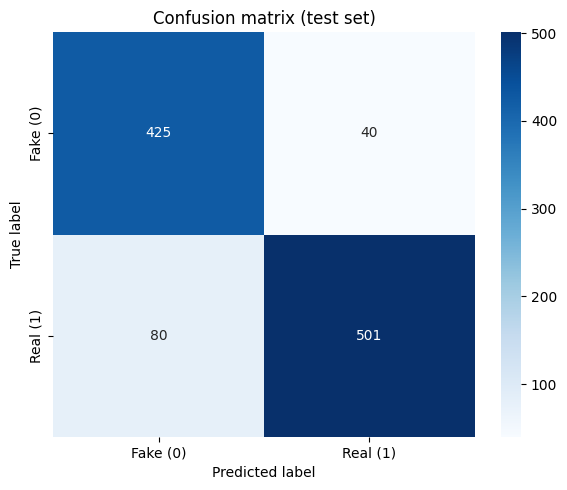

    Done: Model evaluation complete.


In [27]:
# --- [4] MODEL EVALUATION (on held-out test set) ---
print("\n[4] MODEL EVALUATION (confusion matrix, precision, recall, F1, accuracy, classification report)")

y_pred_proba = model.predict(X_test_padded, verbose=0)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("    Metrics on our test set (held-out 20%):")
print(f"       Accuracy:  {accuracy:.4f}")
print(f"       Precision: {precision:.4f}")
print(f"       Recall:    {recall:.4f}")
print(f"       F1 score:  {f1:.4f}")
print("\n    Confusion matrix (rows=true, cols=predicted):")
print(f"                 Predicted")
print(f"                 Fake(0)  Real(1)")
print(f"       True Fake(0)  {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       True Real(1)  {cm[1,0]:5d}   {cm[1,1]:5d}")
print("\n    Classification report (on our test set):")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)'], zero_division=0))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

print("    Done: Model evaluation complete.")
print("="*70)

In [ ]:
# --- [5] OUTPUT: Trained model ---
print("\n[5] OUTPUT: Trained model")

# Save trained model (optional; uncomment to save)
# model.save('trained_lstm_fake_news_model.keras')
# print("    Saved: trained_lstm_fake_news_model.keras")

print("    Trained model summary (with respect to our dataset):")
print(f"       Input shape:  (batch, {MAX_LEN})")
print(f"       Output:      binary probability (Fake/Real)")
print(f"       Test accuracy: {accuracy:.4f}")
print(f"       Test F1:       {f1:.4f}")
print("    The variable 'model' holds the trained LSTM-based model.")
print("    Use model.predict(X_new) for inference on new headlines (after same preprocessing + tokenizer + padding).")

print("\n" + "="*70)
print("MODULE 5 COMPLETED: Model training pipeline done. Trained model ready for inference.")
print("="*70)


[5] OUTPUT: Trained model
    Trained model summary (with respect to our dataset):
       Input shape:  (batch, 80)
       Output:      binary probability (Fake/Real)
       Test accuracy: 0.8958
       Test F1:       0.9089
    The variable 'model' holds the trained LSTM-based model.
    Use model.predict(X_new) for inference on new headlines (after same preprocessing + tokenizer + padding).

MODULE 5 COMPLETED: Model training pipeline done. Trained model ready for inference.


---

# Module 6: Model Inference and Output Generation

This is the final module. It serializes and stores the trained model, retrieves it for inference, and generates fake/real predictions with confidence on our dataset.

**Sub-blocks:**
1. **Input:** Trained LSTM-based model (from Module 5)
2. **Model serialization:** Prepare model and tokenizer for storage
3. **Model storage:** Save model and artifacts to disk
4. **Model retrieval for inference:** Load model and tokenizer from disk
5. **Prediction engine:** Loads the model and runs inference on text
6. **Output generation:** Fake/Real label, confidence percentage, and visualization

In [ ]:
# ======================================================================
# MODULE 6: MODEL INFERENCE AND OUTPUT GENERATION — Sub-block outputs (with respect to our data)
# ======================================================================

print("="*70)
print("MODULE 6: MODEL INFERENCE AND OUTPUT GENERATION")
print("="*70)

# --- [1] INPUT: Trained LSTM-based model (from Module 5) ---
print("\n[1] INPUT: Trained LSTM-based model (from Module 5)")

print("    Inputs from our pipeline:")
print(f"       model: trained BiLSTM (in memory)")
print(f"       keras_tokenizer: fitted on TRAIN only (X_train_prep), vocab size {len(keras_tokenizer.word_index) + 1}")
print(f"       MAX_LEN: {MAX_LEN}")
print(f"       preprocess_tamil_text, tamil_stopwords: from Module 2")
print("    Done: Using trained model and tokenizer for serialization and inference.")
print("="*70)

MODULE 6: MODEL INFERENCE AND OUTPUT GENERATION

[1] INPUT: Trained LSTM-based model (from Module 5)
    Inputs from our pipeline:
       model: trained BiLSTM (in memory)
       keras_tokenizer: fitted on TRAIN only (X_train_prep), vocab size 13119
       MAX_LEN: 80
       preprocess_tamil_text, tamil_stopwords: from Module 2
    Done: Using trained model and tokenizer for serialization and inference.


In [ ]:
# --- [2] MODEL SERIALIZATION ---
print("\n[2] MODEL SERIALIZATION")

# Serialize model to Keras format (architecture + weights)
MODEL_PATH = 'trained_lstm_fake_news_model.keras'
TOKENIZER_PATH = 'inference_tokenizer.pkl'
PARAMS_PATH = 'inference_params.pkl'

# Serialize tokenizer and inference params for later loading
inference_params = {'max_len': MAX_LEN, 'label_names': ['Fake', 'Real']}

print("    Serialized artifacts (with respect to our dataset):")
print(f"       Model: Keras format (architecture + weights)")
print(f"       Tokenizer: fitted on TRAIN only ({len(X_train_prep)} training texts)")
print(f"       Params: max_len={MAX_LEN}, label_names=['Fake','Real']")
print("    Done: Model and tokenizer ready for storage.")
print("="*70)


[2] MODEL SERIALIZATION
    Serialized artifacts (with respect to our dataset):
       Model: Keras format (architecture + weights)
       Tokenizer: fitted on TRAIN only (3344 training texts)
       Params: max_len=80, label_names=['Fake','Real']
    Done: Model and tokenizer ready for storage.


In [ ]:
# --- [3] MODEL STORAGE ---
print("\n[3] MODEL STORAGE")

import os

model.save(MODEL_PATH)
with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(keras_tokenizer, f)
with open(PARAMS_PATH, 'wb') as f:
    pickle.dump(inference_params, f)

print("    Stored artifacts (with respect to our dataset):")
print(f"       Model:     {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1024:.2f} KB)")
print(f"       Tokenizer: {TOKENIZER_PATH} ({os.path.getsize(TOKENIZER_PATH) / 1024:.2f} KB)")
print(f"       Params:    {PARAMS_PATH} ({os.path.getsize(PARAMS_PATH):.0f} B)")
print("    Done: Model and inference artifacts saved to disk.")
print("="*70)


[3] MODEL STORAGE
    Stored artifacts (with respect to our dataset):
       Model:     trained_lstm_fake_news_model.keras (12805.77 KB)
       Tokenizer: inference_tokenizer.pkl (750.02 KB)
       Params:    inference_params.pkl (60 B)
    Done: Model and inference artifacts saved to disk.


In [ ]:
# --- [4] MODEL RETRIEVAL FOR INFERENCE ---
print("\n[4] MODEL RETRIEVAL FOR INFERENCE")

from tensorflow.keras.models import load_model

loaded_model = load_model(MODEL_PATH)
with open(TOKENIZER_PATH, 'rb') as f:
    loaded_tokenizer = pickle.load(f)
with open(PARAMS_PATH, 'rb') as f:
    loaded_params = pickle.load(f)

inference_max_len = loaded_params['max_len']

print("    Retrieved artifacts (with respect to our dataset):")
print(f"       loaded_model: {MODEL_PATH}")
print(f"       loaded_tokenizer: vocab size {len(loaded_tokenizer.word_index) + 1}")
print(f"       inference_max_len: {inference_max_len}")
print("    Done: Model and tokenizer loaded; ready for prediction engine.")
print("="*70)


[4] MODEL RETRIEVAL FOR INFERENCE
    Retrieved artifacts (with respect to our dataset):
       loaded_model: trained_lstm_fake_news_model.keras
       loaded_tokenizer: vocab size 13119
       inference_max_len: 80
    Done: Model and tokenizer loaded; ready for prediction engine.


In [ ]:
# --- [5] PREDICTION ENGINE (loads the model) ---
print("\n[5] PREDICTION ENGINE (uses loaded model for inference)")

def predict_fake_news(text, model=loaded_model, tokenizer=loaded_tokenizer, max_len=inference_max_len,
                      preprocess_func=preprocess_tamil_text, stopwords_list=tamil_stopwords):
    """
    Run inference on a single text: preprocess -> tokenize -> pad -> predict.
    Returns: label ('Fake' or 'Real'), confidence (0-100% for Real).
    """
    if not text or (isinstance(text, float) and np.isnan(text)):
        return 'Unknown', 0.0
    text = str(text).strip()
    preprocessed = preprocess_func(text, stopwords_list)
    seq = tokenizer.texts_to_sequences([preprocessed])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    proba = model.predict(padded, verbose=0)[0][0]
    label = 'Real' if proba >= 0.5 else 'Fake'
    confidence_pct = (proba if label == 'Real' else (1 - proba)) * 100.0
    return label, confidence_pct

print("    Prediction engine: predict_fake_news(text) -> (label, confidence_pct)")
print("    Uses: loaded_model, loaded_tokenizer, preprocess_tamil_text, tamil_stopwords.")
print("    Done: Prediction engine ready for output generation.")
print("="*70)


[5] PREDICTION ENGINE (uses loaded model for inference)
    Prediction engine: predict_fake_news(text) -> (label, confidence_pct)
    Uses: loaded_model, loaded_tokenizer, preprocess_tamil_text, tamil_stopwords.
    Done: Prediction engine ready for output generation.



[6] OUTPUT GENERATION (Fake/Real, confidence %, visualization)
    [Dataset] Sample 1: Fake (99.8% confidence)
       Text:  பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட...
    [Dataset] Sample 2: Fake (89.5% confidence)
       Text:  ஜெ. மரணம் | மருத்துவத் துறையிடம் ஆறுமுகசாமி ஆணைய அறிக்கை: தமிழக அரசு....
    [Dataset] Sample 3: Real (100.0% confidence)
       Text: "புகலிடம் கோரி அமெரிக்காவை நோக்கி அணிவகுத்துச் செல்லும் போது, ​​அமெரிக...
    [Dataset] Sample 4: Real (100.0% confidence)
       Text: "டிரம்ப் வெள்ளை மாளிகையில் இருக்கிறார்! ஹிலாரியை அடைத்து வைப்பதாக அவர்...
    [Dataset] Sample 5: Fake (58.0% confidence)
       Text: வலதுசாரி அமைப்புகளால் நாட்டுக்கு அச்சுறுத்தல்: பிரகாஷ்ராஜ்...
    [Other] Sample 6: Fake (100.0% confidence)
       Text: முதல் மந்திரி நாளை பிரசங்கம் நடத்துவார்...
    [Other] Sample 7: Fake (100.0% confidence)
       Text: வானிலை மாற்றம் குறித்து விடுதலை அறிவிப்பு...
    [Other] Sample 8: Real (80.4% confidence)
       Text: Brea

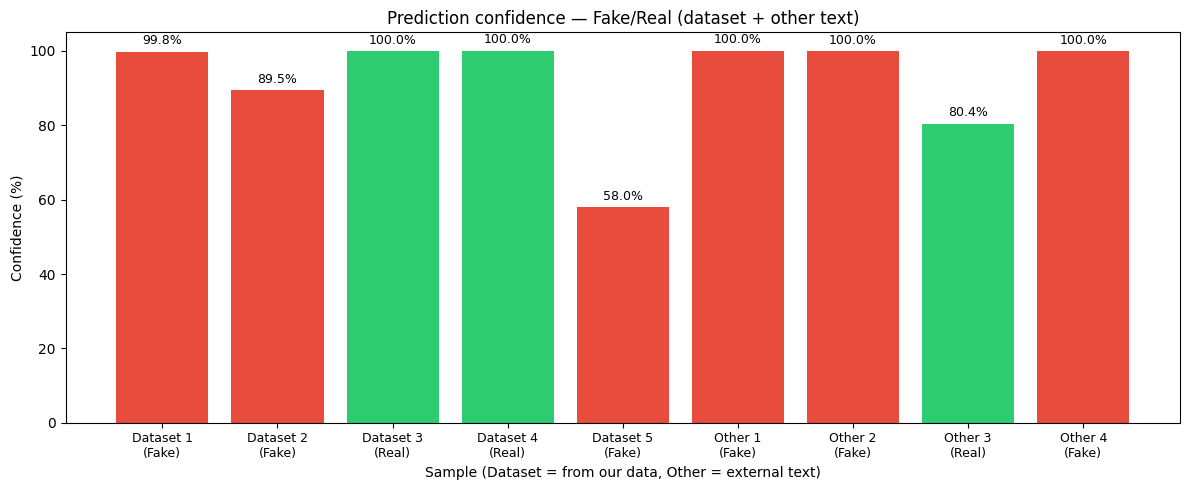

    Done: Output generation (Fake/Real + confidence %) and visualization complete.

    Next: Run the cell below to enter your own news headline and get a prediction.

MODULE 6 COMPLETED: Model inference and output generation done.


In [ ]:
# --- [6] OUTPUT GENERATION: Fake/Real, confidence %, visualization ---
print("\n[6] OUTPUT GENERATION (Fake/Real, confidence %, visualization)")

# Part A: Samples FROM OUR DATASET (X_raw = df['News'])
sample_indices = [0, len(X_raw)//4, len(X_raw)//2, 3*len(X_raw)//4, len(X_raw)-1]
sample_indices = [i for i in sample_indices if i < len(X_raw)]
texts_from_dataset = []
for i in sample_indices:
    texts_from_dataset.append(X_raw.iloc[i] if hasattr(X_raw, 'iloc') else X_raw[i])

# Part B: Other text NOT from our dataset (example headlines for demonstration)
other_texts = [
    "முதல் மந்திரி நாளை பிரசங்கம் நடத்துவார்",
    "வானிலை மாற்றம் குறித்து விடுதலை அறிவிப்பு",
    "Breaking: New policy announced today in Chennai",
    "சினிமா விமர்சனம் இன்று வெளியீடு",
]

# Combine: first dataset samples, then other text
all_texts = texts_from_dataset + other_texts
source_labels = ['Dataset'] * len(texts_from_dataset) + ['Other'] * len(other_texts)

results = []
for i, (text, src) in enumerate(zip(all_texts, source_labels)):
    label, conf = predict_fake_news(text)
    results.append({'text': str(text)[:60] + '...', 'label': label, 'confidence': conf, 'source': src})
    print(f"    [{src}] Sample {i+1}: {label} ({conf:.1f}% confidence)")
    print(f"       Text: {str(text)[:70]}...")

# Confidence visualization (bar chart: dataset + other text)
fig, ax = plt.subplots(figsize=(12, 5))
pred_labels = [r['label'] for r in results]
confidences = [r['confidence'] for r in results]
colors = ['#2ecc71' if l == 'Real' else '#e74c3c' for l in pred_labels]
x = range(len(results))
bars = ax.bar(x, confidences, color=colors)
ax.set_xticks(x)
d_num, o_num = 0, 0
xtick_labels = []
for r in results:
    if r['source'] == 'Dataset':
        d_num += 1
        xtick_labels.append(f"Dataset {d_num}\n({r['label']})")
    else:
        o_num += 1
        xtick_labels.append(f"Other {o_num}\n({r['label']})")
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_ylabel('Confidence (%)')
ax.set_xlabel('Sample (Dataset = from our data, Other = external text)')
ax.set_title('Prediction confidence — Fake/Real (dataset + other text)')
ax.set_ylim(0, 105)
for i, (bar, c) in enumerate(zip(bars, confidences)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{c:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("    Done: Output generation (Fake/Real + confidence %) and visualization complete.")
print("\n    Next: Run the cell below to enter your own news headline and get a prediction.")
print("\n" + "="*70)
print("MODULE 6 COMPLETED: Model inference and output generation done.")
print("="*70)

In [ ]:
# --- User input: Enter your own news headline to predict Fake/Real ---
print("\n" + "="*70)
print("USER INPUT: Enter your own news headline to predict")
print("="*70)
print("\nTip for typing Tamil:")
print("  • Windows: Settings > Time & language > Language > Add a language > Tamil.")
print("    Then press Win+Space to switch to Tamil keyboard.")
print("  • Mac: System Preferences > Keyboard > Input Sources > + > Tamil.")
print("  • Or use an online Tamil keyboard (search 'Tamil keyboard online'), type there, copy and paste below.")
print("\nYou can also type or paste English or mixed Tamil-English text.\n")

user_news = input("Enter or paste your news headline here: ").strip()

if user_news:
    pred_label, pred_conf = predict_fake_news(user_news)
    print("\n--- Your prediction ---")
    print(f"   Headline: {user_news[:80]}{'...' if len(user_news) > 80 else ''}")
    print(f"   Prediction: {pred_label}")
    print(f"   Confidence: {pred_conf:.1f}%")
else:
    print("No text entered. Run the cell again and type or paste a headline.")


USER INPUT: Enter your own news headline to predict

Tip for typing Tamil:
  • Windows: Settings > Time & language > Language > Add a language > Tamil.
    Then press Win+Space to switch to Tamil keyboard.
  • Mac: System Preferences > Keyboard > Input Sources > + > Tamil.
  • Or use an online Tamil keyboard (search 'Tamil keyboard online'), type there, copy and paste below.

You can also type or paste English or mixed Tamil-English text.

Enter or paste your news headline here: 
No text entered. Run the cell again and type or paste a headline.
